**BEST_OF OPTIONS**

In [116]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

# QUESTION 0 : 
**Implémentation de la FdR $\mathcal{N}(0, 1)$ approximée**

In [117]:
def q(x) : 
    """ Approximation de la fonction de répartition de la loi normale centrée réduite """
    b0 = 0.2316419
    b1 = 0.319381530
    b2 =-0.356563782
    b3 = 1.781477937
    b4 =-1.821255978
    b5 = 1.330274429

    t= 1.0/(1.0 + b0*x)

    dl = b1*t + b2*t**2 + b3*t**3 + b4*t**4 + b5*t**5
    dl = dl * np.exp(-0.5*x**2)/np.sqrt(2.0*np.pi)
    return (1 - dl)

`Question 1 et Question 2 cf tex`

# QUESTION 3 : 

In [118]:
# Paramètres pour les simulations 

T = 1.5           
r = 0.02          
K = 1.0           
rho = 0.3         
S0 = [1.0, 1.0, 1.0]      
sigma = [0.3, 0.3, 0.3] 
d=3

N=10000

In [119]:
def normal_standard(d, N) : 
    """
    Génère une matrice (d, N) de variables normales standard
    N = nombre de simulations, 
    d = dimension du vecteur gaussien standard à générer.
    """

    U = npr.random((d,N))
    V = npr.random((d,N))

    X = np.sqrt(-2 * np.log(U))*np.cos(2*np.pi*V)

    return X 

Le but de la question 3 est juste de générer un vecteur gaussien $$ W(T) := (W_1(T), W_2(T), W_3(T)) $$ de matrice de corrélation $\Gamma := (\text{Cov}(W_i(T), W_j(T))/{s_i s_j})_{ij}$, avec $s_i := \sqrt{\text{Var}(W_i(T))} = \sqrt{T}$ car m-b-s.  

Ainsi sa matrice de covariation est $\Sigma := T \, \Gamma$. 

Nous utiliserons Cholesky : $$ \Gamma = A A^{\top} $$ pour $A$ triangulaire inférieure. Et, nous avons donc  $$ W(T) \underset{loi}{ = } \sqrt{T} \, A \, \mathcal{N}(0, I_3) \, . $$

In [120]:
def simulate_WT (N, t=T, rho=rho, d=3) :
    """
    Génère une simulation du vecteur colonne gaussien (W_1(t), W_2(t), ..., W_d(t)), de matrice de corrélation Gamma.
    N = nombre de simulations : nombre de colonnes de la matrice retournée
    d = dimension du vecteur gaussien à simuler : nombre de lignes de la matrice retournée
    """
    G = normal_standard(d, N)

    Gamma = np.eye(d) + rho * (np.ones((d,d)) - np.eye(d)) 
    
    A = np.linalg.cholesky(Gamma)

    WT = np.sqrt(t) * A @ G

    return WT
    
    

Text(0.5, 0, 'W3(T)')

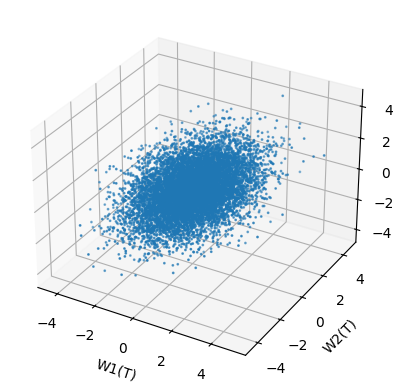

In [121]:
##########################
##### Visualisation  ##### 
##########################

WT = simulate_WT(N, T, rho)

fig = plt.figure()
ax=fig.add_subplot(projection='3d')

ax.scatter(WT[0], WT[1], WT[2], s=1)

ax.set_xlabel('W1(T)')
ax.set_ylabel('W2(T)')
ax.set_zlabel('W3(T)')

On estime ensuite par Monte-Carlo classique (i.e. LGN) $$ P^1 := e^{-rT} \mathbf{E} \left[ \max_i S_T^i \right] - K e^{-rT} $$
où $$  S^i_t = \exp\left(\log( S^i_t)\right) = s^i_0\exp\left(\left(r - \dfrac{\sigma_i^2}{2}\right)t + \sigma_i W^i_t\right) \quad p.s. $$

In [122]:
def simulate_St (n, t=T, rho=rho, sigma=sigma, S0=S0, r=r, d=3) :
    """
    Génère une matrice (d, n) de prix d'actifs à l'instant t.
    """
    S0_vec = np.array(S0).reshape(-1,1)
    sigma_vec = np.array(sigma).reshape(-1,1)

    Wt = simulate_WT(n, t=t, rho=rho, d=d)

    # Calcul de S(t) (matrice 3*n)
    # sigma_vec * Wt : calcule produit terme à terme. Mais les termes de Wt sont des lignes, qui simule Wi. 
    # et le + fait aussi la somme terme à terme. 

    St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt) # taille d*n

    return St

In [123]:
# mcc pour monte carlo classique
def mcc_P1(n, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K):

    St = simulate_St(n, t=T, rho=rho, sigma=sigma, S0=S0, r=r)
    
    # On prend le max de chaque colonne (axis=0)
    max_ST = np.max(St, axis=0) # taille 3*n
    
    # Prix estimé
    return np.exp(-r * t) * (np.mean(max_ST) - K)

mcc_P1(10000000)

np.float64(0.30039857828856437)

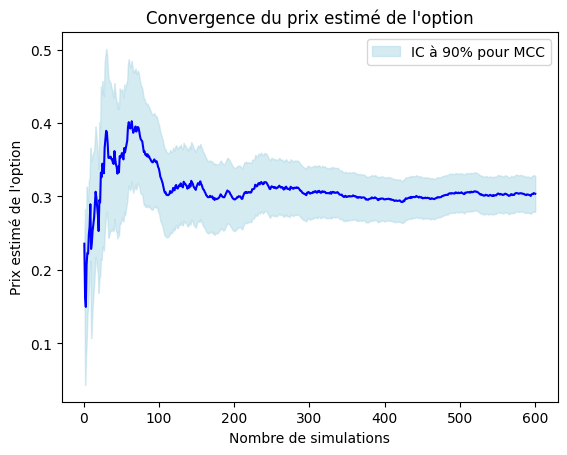

In [124]:
def visualise_mcc_P1 (Nmax, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K) :

    S0_vec = np.array(S0).reshape(-1,1)
    sigma_vec = np.array(sigma).reshape(-1,1)
    
    Wt = simulate_WT(Nmax, t, rho) 
    
    St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt) 
    
    # On prend le max pour chaque colonne (axis=0)
    max_St = np.max(St, axis=0) 

    V = max_St

    moyennes = np.cumsum(V) / np.arange(1, Nmax +1)
    moyennes_carrees = np.cumsum(V**2) / np.arange(1, Nmax +1)

    # variances[n] = variance empirique débiaisée de l'échantillon (V1, ..., V_n), divisé par n. (cf. QUESTION 5) :
    variances =  ((moyennes_carrees - moyennes**2) / np.maximum(1, np.arange(1, Nmax +1) -1))

    # intervalles de confiance à 90% :
    ica_inf = np.exp(-r * t) * (moyennes - 1.645 * np.sqrt(variances) - K)
    ica_sup = np.exp(-r * t) * (moyennes + 1.645 * np.sqrt(variances) - K)

    prix_estimes = np.exp(-r * t) * (moyennes - K)
    
    plt.plot(np.arange(1, Nmax +1), prix_estimes, color='blue')
    plt.fill_between(np.arange(1, Nmax +1), ica_inf, ica_sup, color='lightblue', alpha=0.5, label='IC à 90% pour MCC')
    plt.legend()
    plt.xlabel('Nombre de simulations')
    plt.ylabel('Prix estimé de l\'option')
    plt.title('Convergence du prix estimé de l\'option')
    

visualise_mcc_P1(600)
# =0.3

# QUESTION 4 : 

In [125]:
# mca pour monte carlo antithétique

def mca_P1(n, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K):
    
    S0_vec = np.array(S0).reshape(-1,1)
    sigma_vec = np.array(sigma).reshape(-1,1)

    Wt = simulate_WT(n, t, rho)
    
    # Calcul de "max S(Wt)" 
    St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt)
    max_St = np.max(St, axis=0) 
    
    # Calcul de "max S(-Wt), pur le même Wt... "
    St_antithetic = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * (-Wt))
    max_St_antithetic = np.max(St_antithetic, axis=0)

    V = 0.5 * (max_St + max_St_antithetic)
    
    return np.exp(-r * t) * (np.mean(V) - K)

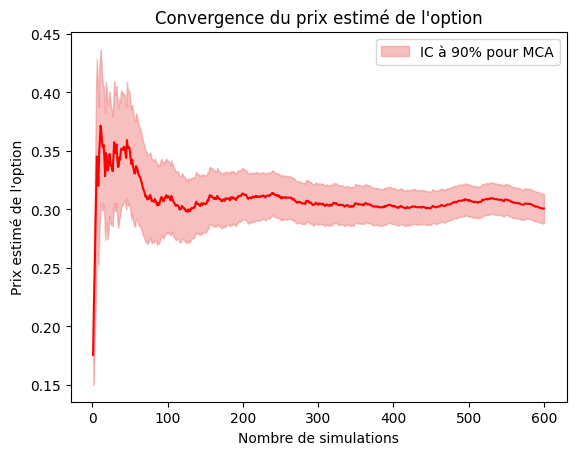

In [126]:
def visualise_mca_P1(Nmax, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K) :
    S0_vec = np.array(S0).reshape(-1,1)
    sigma_vec = np.array(sigma).reshape(-1,1)
    
    Wt = simulate_WT(Nmax, t, rho) 

    # Calcul de "max S(Wt)" 
    St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt)
    max_St = np.max(St, axis=0) 
    
    # Calcul de "max S(-Wt), pur le même Wt... "
    St_antithetic = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * (-Wt))
    max_St_antithetic = np.max(St_antithetic, axis=0)

    V = 0.5 * (max_St + max_St_antithetic)

    moyennes = np.cumsum(V) / np.arange(1, Nmax +1)
    moyennes_carrees = np.cumsum(V**2) / np.arange(1, Nmax +1)

    # variances[n] = variance empirique débiaisée de l'échantillon (V1, ..., V_n), divisé par n. (cf. QUESTION 5) :
    variances =  ((moyennes_carrees - moyennes**2) / np.maximum(1, np.arange(1, Nmax +1) -1))

    # intervalles de confiance à 90% :
    ica_inf = np.exp(-r * t) * (moyennes - 1.645 * np.sqrt(variances) - K)
    ica_sup = np.exp(-r * t) * (moyennes + 1.645 * np.sqrt(variances) - K)

    prix_estimes = np.exp(-r * t) * (moyennes - K)

    
    plt.plot(np.arange(1, Nmax +1), prix_estimes, color='red')
    plt.fill_between(np.arange(1, Nmax +1), ica_inf, ica_sup, color='lightcoral', alpha=0.5, label='IC à 90% pour MCA')
    plt.legend()
    plt.xlabel('Nombre de simulations')
    plt.ylabel('Prix estimé de l\'option')
    plt.title('Convergence du prix estimé de l\'option')

visualise_mca_P1(600)
    

# QUESTION 5 :

Pour mcc et mca, c'est le même principe. Notons $V = \max_i S_T^i $ (pour le cas mcc), ou $V =  0.5 \times [\max_i S_T^i(W_T) + \max_i S_T^i (-W_T) ]$ (pour le mca). 

Pour déterminier les ICA : 

TCL + Slutzky : 

$$ \sqrt{n}/{\hat{s_n}} \left( \delta_n - \mathbf{E}(\max_i S_T^i) \right)  \to N(0, 1) $$

où $$ \delta_n = \dfrac{1}{n} \sum_{i=1}^n V_i $$ avec $V_i$ obserations de $V$ ; $\hat{s_n}^2$ variance empirique débiaisé de l'échantillon $(V_1, \ldots, V_n)$.

D'où l'ICA à $90\%$ suivant : 

$$ [\delta_n \pm q_{0.95} \hat{s_n} / \sqrt{n}] \, . $$

Notons que $$ \hat{s_n}^2 = \text{Var empirique débiaisé} (V_1, \ldots, V_n) = \dfrac{n}{n-1} \left( \text{moyenne}(V_i^2) - \text{moyenne} (V_i) ^2 \right) \, .$$

Dès lors, 

$$ \hat{s_n}^2 / n = \dfrac{1}{n-1} \left( \text{moyenne}(V_i^2) - \text{moyenne} (V_i) ^2 \right) \, .$$

Note : déterminer l'ICA seulement pour $\delta_n$ permet facilement de trouver l'ICA sur $ e^{-rT} (\delta_n - K) $ : suffit de faire $-K$ puis $\times e^{-rT}$ aux bornes.

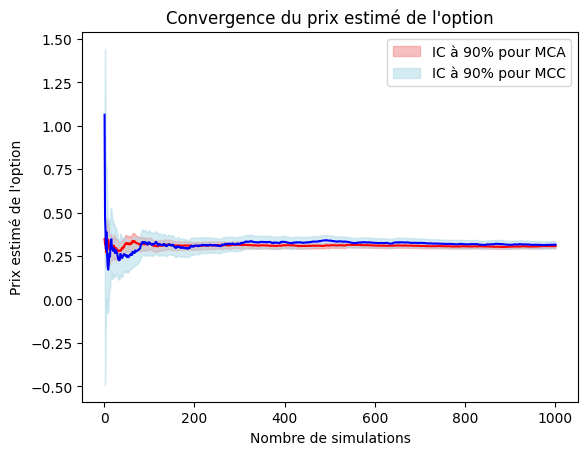

In [127]:
visualise_mca_P1(1000)
visualise_mcc_P1(1000)

# QUESTION 6 : 

L'IC asymptotique va se resserrer au fur et à mesure que n grandit, les bornes convergant vers $\mathbf{E}(\max_i S_t^i))$. Choisissons donc un critère sur la largeur de l'ICA. Nous pouvons nous fixer par exemple une erreur à $1 \%$ du strike $K$. On applique ce critère seulement sur l'ICA de MCA (qui a une largeur se resserant plus vite...)

Théoriquement, nous savons que la largeur de l'Intervalle de confiance vaut : 
$$ L_n := e^{-rT} \times 2 \times q_{0.95} \, s / \sqrt{n} \, .$$

Nous voulons $ L_n < 0.01 K $, ce qui équivaut à 
$$ e^{-2 r T} \left( \dfrac{2 \times q_{0.95} \,  s}{0.01 K} \right) ^2 < n $$

Nous choisirons donc $n = \text{partie entière} \, \left( e^{-2rT} \left( \dfrac{2 \times q_{0.95} \,  \hat{s_N}}{0.01 K} \right) ^2 \right) $

pour un $N$ très très grand (10 000 000).

In [128]:
# Choix du nombre de simulations/trajectoires pour une précision de 1% du strike K :
N = 10000000

S0_vec = np.array(S0).reshape(-1,1)
sigma_vec = np.array(sigma).reshape(-1,1)
    
Wt = simulate_WT(N, T, rho) 

# Calcul de "max S(Wt)" 
St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * T + sigma_vec * Wt)
max_St = np.max(St, axis=0) 
    
# Calcul de "max S(-Wt), pur le même Wt... "
St_antithetic = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * T + sigma_vec * (-Wt))
max_St_antithetic = np.max(St_antithetic, axis=0)

V = 0.5 * (max_St + max_St_antithetic)

moyennes = np.cumsum(V) / np.arange(1, N +1)

# écart type empirique débiaisé pour N grand
sdN = np.std(V, ddof=1) # ddof = 1 pour avoir un débiaisé.

goodn = round( np.exp(- 2 * r * T) * (2 * 1.645 * sdN / (0.01 * K))**2  )

print(goodn)



# goodn = 4200 est très bien !! 



4168


Text(0.5, 1.0, "Prix estimé de l'option par MCA en fonction de rho")

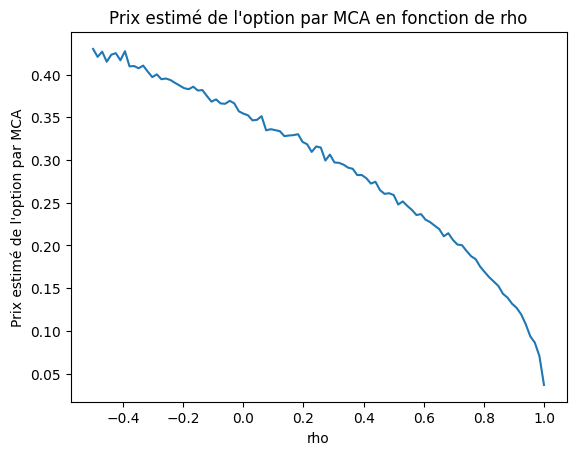

In [129]:
# Tracés estimateurs MCA de P1 pour différents rho. 

goodn = 4200

rhos = np.linspace(-0.499, 0.999, 100)
mca_P1_rhos = np.zeros(len(rhos))

for i in range(len(rhos)) : 
    mca_P1_rhos[i] = mca_P1(goodn, t=T, rho=rhos[i])

plt.plot(rhos, mca_P1_rhos)
plt.xlabel('rho')
plt.ylabel('Prix estimé de l\'option par MCA')
plt.title('Prix estimé de l\'option par MCA en fonction de rho')


Plus les actifs sont corrélés, moins l'option est chère. Pus precisémment :


Si $\rho = 1$ : Parfaitement corrélés, cela revient à avoir acheté qu'une seue action. Le fait de prendre le max sur trois actions perd tout son intéret. 

Si $\rho = 0$, c'est décorrélé. C'est tout de même bien ! On prend un max sur trois actions, a priori, on a trois fois plus de chance d'avoir des actions plus importantes..

Si $\rho<0$ : corrélation négative. Si l'un diminue, l'autre augmente. Cela renforce encore plus les chances d'avoir un max des trois prix important ! POur $\rho = 0$, même si l'un diminue, cela ne fait pas nécessairement augmenter le prix d'un des autres actifs. 

`Question 7 et Question 8 cf tex`

# QUESTION 7 (partie numérique)

Nous avons l'expression analystique de $P^{E, i}$ : 
$$ P^{E, i} = K e^{-rT} F(A_i) - s_0^i F(A_i - \sigma_i \sqrt{T}) $$

et $ A_i = \dfrac{\log\left(\frac{K}{s_0^i}\right) - \left(r - \frac{\sigma_i^2}{2}\right)T}{\sigma_i\sqrt{T}} $, 
et $F$ fonction de répartition de la N(0, 1).

Rappelons encore que $$  S^i_t = \exp\left(\log( S^i_t)\right) = s^i_0\exp\left(\left(r - \dfrac{\sigma_i^2}{2}\right)t + \sigma_i W^i_t\right) \quad p.s. $$

In [130]:
def PE (i, t=T, sigma=sigma, S0=S0, r=r, K=K):
    """ Prix exact du put Européen pour l'actif i, avec les paramètres donnés. """

    A = (np.log(K/S0[i-1]) - (r - 0.5*sigma[i-1]**2)*t) / (sigma[i-1]*np.sqrt(t))
    
    return K*np.exp(-r*t)*q(A) - S0[i-1]*q(A - sigma[i-1]*np.sqrt(t))

# QUESTION 9 : 

Un put sur Best-Of a pour expression : 

$$ P^2 = e^{-rT} \mathbf{E} \left[ \left( K - \max_{i \in \{1, 2, 3\} } S_i(T) \right)_+ \right] $$

In [131]:
def mca_P2(n, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K, d=3):
    """
    n : nombre de trajectoires / ordre du Monte Carlo
    d : nombre d'actifs composant le panier (utile pour la suite)
    """
    
    S0_vec = np.array(S0).reshape(-1,1) # vecteur colonne
    sigma_vec = np.array(sigma).reshape(-1,1) # vecteur colonne

    Wt = simulate_WT(n, t, rho, d)
    
    # Calcul de "max S(Wt)" 
    St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt)
    max_St = np.max(St, axis=0) 
    
    # Calcul de "max S(-Wt), pur le même Wt... "
    St_antithetic = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * (-Wt))
    max_St_antithetic = np.max(St_antithetic, axis=0)

    # X(Wt) = (K - max S(Wt))_+
    X_Wt = np.maximum(0, K - max_St)
    X_Wt_antithetic = np.maximum(0, K - max_St_antithetic)

    V = 0.5 * (X_Wt + X_Wt_antithetic)
    
    return np.exp(-r * t) * np.mean(V)

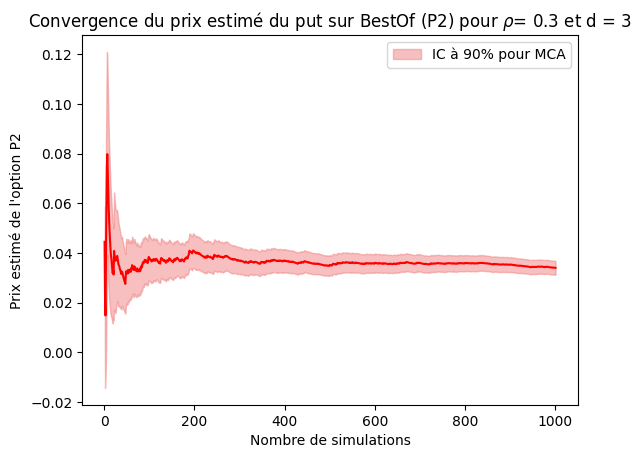

In [132]:
# convergence de mca_P2  et ICA à 90% 

def visualise_mca_P2(Nmax, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K, d=3) :
    S0_vec = np.array(S0).reshape(-1,1)
    sigma_vec = np.array(sigma).reshape(-1,1)
    
    Wt = simulate_WT(Nmax, t, rho, d) 

    # Calcul de "max S(Wt)" 
    St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt)
    max_St = np.max(St, axis=0) 
    
    # Calcul de "max S(-Wt), pur le même Wt... "
    St_antithetic = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * (-Wt))
    max_St_antithetic = np.max(St_antithetic, axis=0)

    # X(Wt) := (K - max S(Wt))_+
    X_Wt = np.maximum(0, K - max_St)
    X_Wt_antithetic = np.maximum(0, K - max_St_antithetic)

    V = 0.5 * (X_Wt + X_Wt_antithetic)

    moyennes = np.cumsum(V) / np.arange(1, Nmax +1)
    moyennes_carrees = np.cumsum(V**2) / np.arange(1, Nmax +1)

    # variances[n] = variance empirique débiaisée de l'échantillon (V1, ..., V_n), divisé par n. (cf. QUESTION 5) :
    variances =  ((moyennes_carrees - moyennes**2) / np.maximum(1, np.arange(1, Nmax +1) -1))

    # intervalles de confiance à 90% :
    ica_inf = np.exp(-r * t) * (moyennes - 1.645 * np.sqrt(variances))
    ica_sup = np.exp(-r * t) * (moyennes + 1.645 * np.sqrt(variances))

    prix_estimes = np.exp(-r * t) * moyennes

    
    plt.plot(np.arange(1, Nmax +1), prix_estimes, color='red')
    plt.fill_between(np.arange(1, Nmax +1), ica_inf, ica_sup, color='lightcoral', alpha=0.5, label='IC à 90% pour MCA')
    plt.legend()
    plt.xlabel('Nombre de simulations')
    plt.ylabel('Prix estimé de l\'option P2')
    plt.title(rf"Convergence du prix estimé du put sur BestOf (P2) pour $\rho$= {rho} et d = {d}")

visualise_mca_P2(1000)
    


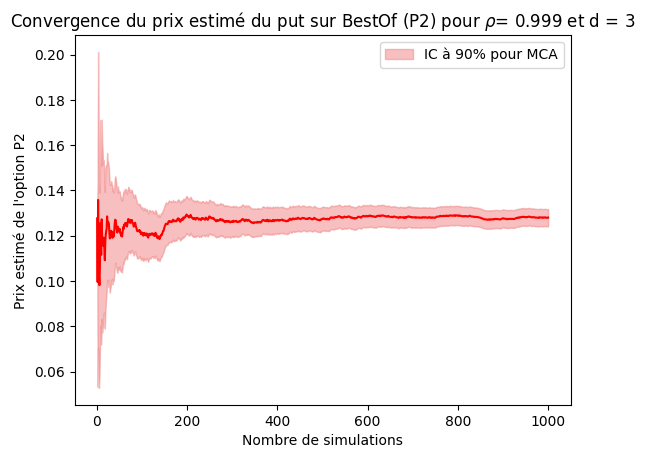

In [133]:
# Même tracé pour rho=1 (ou presque) :
visualise_mca_P2(1000, rho=0.999)

Nous avons obtenu en question 8 : 
$$ P^2 \leqslant \underset{i}{\text{moyenne}} \: P^{E, i} $$

Et, l'expression analystique de $P^{E, i}$ vaut : 
$$ P^{E, i} = K e^{-rT} F(A_i) - s_0^i F(A_i - \sigma_i \sqrt{T}) $$

et $ A_i = \dfrac{\log\left(\frac{K}{s_0^i}\right) - \left(r - \frac{\sigma_i^2}{2}\right)T}{\sigma_i\sqrt{T}} $, 
et $F$ fonction de répartition de la $\mathcal{N}(0, 1)$.

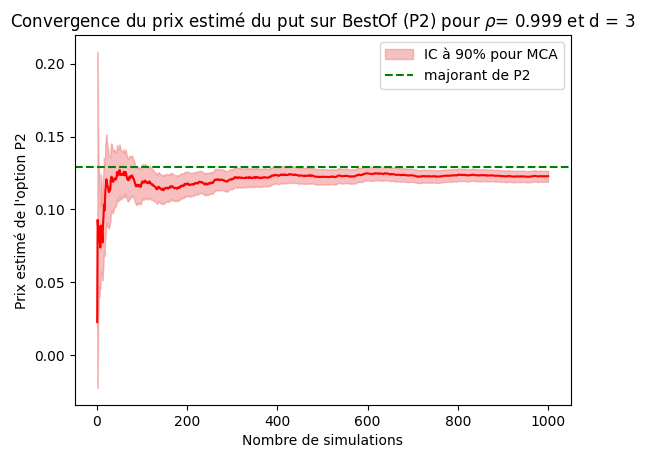

In [134]:
majP2=0
for i in range(d) : 
    majP2 += PE(i=i, t=T, sigma=sigma, S0=S0, r=r, K=K)

majP2 = 1/d * majP2
visualise_mca_P2(1000, rho=0.999)
plt.axhline(y=majP2, color='green', linestyle='--', label='majorant de P2')
plt.legend()
plt.show()


C'est logique ! En effet, $\rho=1$ signifie que tous les actifs $S_i$ évoluent exactement de la même manière. Plus encore, étant donné que les vecteurs $\sigma$ et $S_0$ sont égaux, ce qui différentie les $S_i$ ne réside que dans le m-b-s $((W_t^i)_t)_i$. Ces derniers étant parfaitement corrélés, en les simulant un grand nombre de fois, cela revient à avoir simulé trois fois le même m-b-s. Ainsi, prendre $\max_i S_i$ revient en fait à ne prendre qu'un seul actif $S_i$ tout du long de la simulation - par exemple $S_1$. Notre put sur Best-Of coïncide donc avec un put Européen. 

# QUESTION 10 : 

On utilise le même critère que tout à l'heure, sur la largeur de l'ICA : nous la voulons $< 0.01 \, K$. Nous voulons donc un nombre de trajectoire $n$ tel que 

$$ n = \text{partie entière} \, \left( e^{-2rT} \left( \dfrac{2 \times q_{0.95} \,  \hat{s_N}}{0.01 K} \right) ^2 \right) $$

pour un $N$ très très grand (10 000 000).

In [135]:
# Choix du nombre de simulations/trajectoires pour une précision de 1% du strike K :
N = 10000000

S0_vec = np.array(S0).reshape(-1,1)
sigma_vec = np.array(sigma).reshape(-1,1)
    
Wt = simulate_WT(N, T, rho) 

# Calcul de "max S(Wt)" 
St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * T + sigma_vec * Wt)
max_St = np.max(St, axis=0) 
    
# Calcul de "max S(-Wt), pur le même Wt... "
St_antithetic = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * T + sigma_vec * (-Wt))
max_St_antithetic = np.max(St_antithetic, axis=0)

# X(Wt) := (K - max S(Wt))_+
X_Wt = np.maximum(0, K - max_St)
X_Wt_antithetic = np.maximum(0, K - max_St_antithetic)

V = 0.5 * (X_Wt + X_Wt_antithetic)

moyennes = np.cumsum(V) / np.arange(1, N +1)

# écart type empirique débiaisé pour N grand
sdN = np.std(V, ddof=1) # ddof = 1 pour avoir un débiaisé.

goodn = round( np.exp(- 2 * r * T) * (2 * 1.645 * sdN / (0.01 * K))**2  )

print(goodn)



# goodn = 300 est très bien !! (semble en fait ne jamais dépasser 293 pour une précision de 1% du strike K)



291


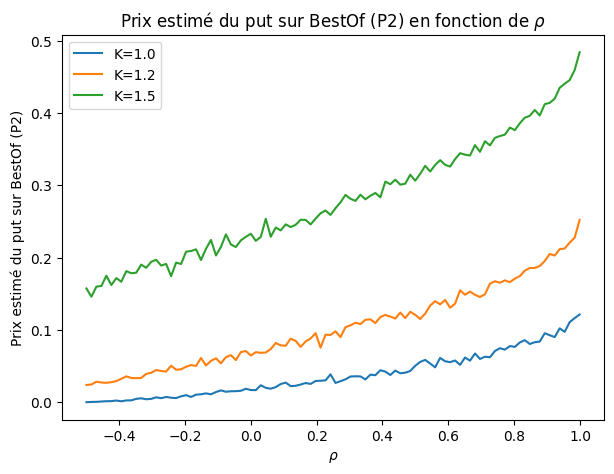

In [136]:
# Tracé de l'estimateur MCA de P2 en fonction de rho, pour K = 1, 1.2, 1.5

goodn = 300
rhos = np.linspace(-0.499, 0.999, 100)
Ks = [1.0, 1.2, 1.5]

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.set_title(r'Prix estimé du put sur BestOf (P2) en fonction de $\rho$')
ax.set_xlabel(r'$\rho$')
ax.set_ylabel('Prix estimé du put sur BestOf (P2)')

for k in range(3) :
    
    mca_P2_rhos = np.zeros(len(rhos))

    for j in range(len(rhos)) : 
        mca_P2_rhos[j] = mca_P2(goodn, t=T, rho=rhos[j], K=Ks[k])

    ax.plot(rhos, mca_P2_rhos)
    
ax.legend([f'K={Ks[0]}', f'K={Ks[1]}', f'K={Ks[2]}'])

Plus le prix du strike K (i.e. le montant auquel on vend au minimum, à l'échéance T) est important, et plus le prix estimé du put sur Best Of est important. En effet, plus $K$ est important, et plus la somme garantie est importante ! 

De plus, 

Si $\rho = 1$ : Parfaitement corrélés, cela revient à avoir acheté qu'une seule action. Le fait de prendre le max sur trois actions perd tout son intéret pour l'acheteur, cela fait comme si je n'avais qu'acheté qu'une seule action. Il y a plus de chance que je vende au prix du strike $K$ en étant gagnant ($\max S_i(T) < K$) qu'en étant perdant ($\max S_i(T) > K$). 

Si $\rho = 0$, c'est décorrélé. On prend un max sur trois actions, a priori, on a trois fois plus de chance d'avoir une  des actions qui dépasse le prix du strike $K$ à l'échéance $T$ : nous sommes donc, en tant que vendeur, moins gagnant. 

Si $\rho<0$ : corrélation négative. Si l'un diminue, l'autre augmente. Cela renforce encore plus les "chances" d'avoir un max des trois prix important, et qui dépassera donc $K$ !

# QUESTION 11

Rappelons que 
$$  S^1_t = \exp\left(\log( S^1_t)\right) = s^1_0\exp\left(\left(r - \dfrac{\sigma_1^2}{2}\right)t + \sigma_1 W^1_t\right) \quad p.s. $$

# QUESTION 12 : 

à faire après que la Q7 soit faite

# QUESTION 13 : 
Nous n'avons plus seulement $3$ actifs, mais $d$ (enfin, $N$ dans l'énoncé mais osef des notations). 

La matrice de corrélation se généralise trivialement (quel dédain!): 

$$ 
\Gamma = 
\begin{pmatrix}
1    & \rho   & \cdots & \rho \\
\rho & \ddots & \ddots   & \vdots \\
\vdots & \ddots &  \ddots & \rho \\
\rho & \cdots &  \rho & 1 \\
\end{pmatrix} \in \R^{d \times d} 
$$

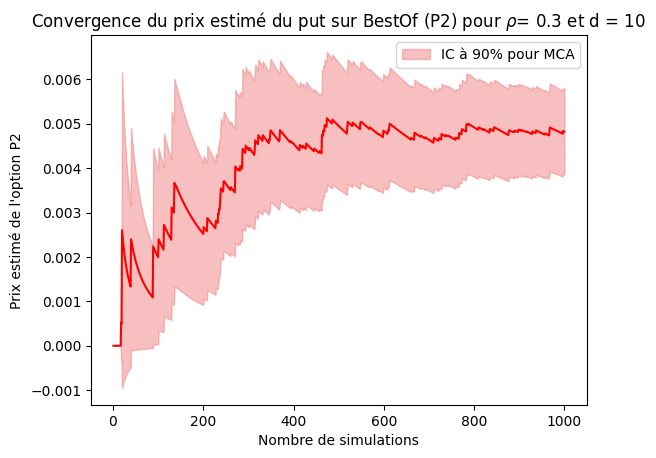

In [137]:
d=10
S0 = np.ones(d)
sigma = 0.3 * np.ones(d)

visualise_mca_P2(1000, S0=S0, sigma=sigma, d=d)

In [138]:
# Choix du nombre de simulations/trajectoires pour une précision de 1% du strike K :
N = 10000000

S0_vec = np.array(S0).reshape(-1,1)
sigma_vec = np.array(sigma).reshape(-1,1)
    
Wt = simulate_WT(N, T, rho, d=d) 

# Calcul de "max S(Wt)" 
St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * T + sigma_vec * Wt)
max_St = np.max(St, axis=0) 
    
# Calcul de "max S(-Wt), pur le même Wt... "
St_antithetic = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * T + sigma_vec * (-Wt))
max_St_antithetic = np.max(St_antithetic, axis=0)

# X(Wt) := (K - max S(Wt))_+
X_Wt = np.maximum(0, K - max_St)
X_Wt_antithetic = np.maximum(0, K - max_St_antithetic)

V = 0.5 * (X_Wt + X_Wt_antithetic)

moyennes = np.cumsum(V) / np.arange(1, N +1)

# écart type empirique débiaisé pour N grand
sdN = np.std(V, ddof=1) # ddof = 1 pour avoir un débiaisé.

goodn = round( np.exp(- 2 * r * T) * (2 * 1.645 * sdN / (0.01 * K))**2  )

print(goodn)



# goodn = 40 est très bien !! (semble en fait ne jamais dépasser 37 pour une précision de 1% du strike K, avec d=10)



37


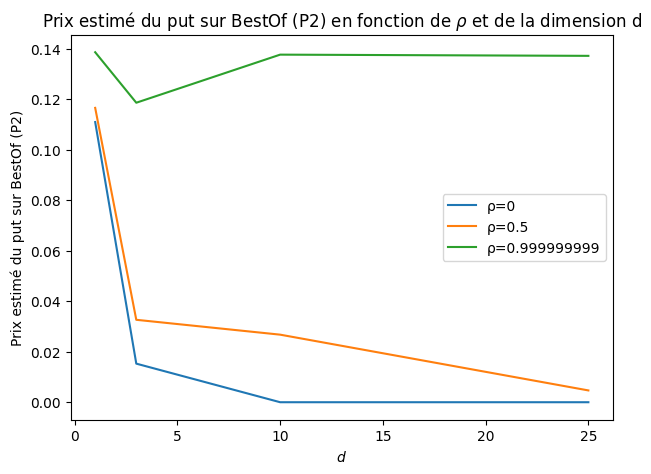

In [139]:
# Tracé de l'estimateur MCA de P2 en fonction de N et rho

goodn = 40
rhos = [0, 0.5, 0.999999999]
ds = [1, 3, 10, 25]

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.set_title(r'Prix estimé du put sur BestOf (P2) en fonction de $\rho$ et de la dimension d')
ax.set_xlabel(r'$d$')
ax.set_ylabel('Prix estimé du put sur BestOf (P2)')

for k in range(3) :
    
    mca_P2_d = np.zeros(len(ds))

    for j in range(len(ds)) : 
        S0 = np.ones(ds[j])
        sigma = 0.3 * np.ones(ds[j])
        mca_P2_d[j] = mca_P2(goodn, t=T, rho=rhos[k], S0=S0, sigma=sigma, d=ds[j])

    ax.plot(ds, mca_P2_d)
    
ax.legend([f'ρ={rhos[0]}', f'ρ={rhos[1]}', f'ρ={rhos[2]}'])

Si $\rho = 0$, tous les actifs sont décoréllés. 
Alors, plus nous avons d'actifs dans notre panier, plus il y a de chances que le prix max de nos actifs, arrivés à l'échéance $T$, dépassent notre strike $K$ (prix préalablement convenu de la vente). Nous ne vendrons pas : d'où la valeur $0$. 

Si $\rho=0.5$, les actifs sont un peu liés mais garde tout de même une marge de liberté. Cette liaison permet de réduire les chances qu'un des actifs explose en prix (comparé au cas où il n'y a pas de corrélation du tout). Ainsi, le prix du put réduit, mais plus lentement que pour le cas précédent. 

Si $\rho = 1$, la corrélation est totale : avoir dans son panier $1$ ou $25$ actifs ne change pas le résultat, étant donnés que tous les actifs évolueront exactement de la même manière. Ceci est donc constant prà notre nombre d'actifs $d$.

`Question 14 et Question 15 cf tex`